<a href="https://colab.research.google.com/github/sophiadapot/stats507-coursework/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📸 The NumPy Photo Lab
### *Your Journey into Data Science with Python* — NumPy Project

Today you'll discover a secret: **every digital photo is just a NumPy array.**
Which means everything we learned about arrays — slicing, broadcasting, boolean
indexing, ufuncs, statistics — can be used to *edit photos*, build your own
Instagram filters, do green-screen movie magic, and even catch photo forgers.

**The One Rule of the Photo Lab:** 🚫 **No `for` loops over pixels.**
Every effect must be built with NumPy operations on whole arrays.

**How to work:** run every cell top to bottom. Cells marked **`# TODO`** are yours.
Checkpoints (✅) tell you what you should see. Get a code check from Kanij or
Khanysha before moving to the next Part.

## Part 0 · Setup — a photo *is* an array

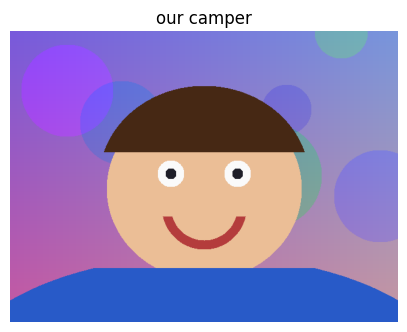

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def load(path):
    '''Load a PNG as a uint8 RGB array with values 0-255.'''
    img = plt.imread(path)
    if img.dtype != np.uint8:              # matplotlib loads PNGs as floats 0-1
        img = (img * 255).round().astype(np.uint8)
    return img[:, :, :3]                   # drop the alpha channel

def show(*imgs, titles=None, gray=False):
    '''Display one or more images side by side.'''
    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 4))
    axes = np.atleast_1d(axes)
    for i, (ax, im) in enumerate(zip(axes, imgs)):
        ax.imshow(im, cmap="gray" if gray else None, vmin=0, vmax=255)
        ax.axis("off")
        if titles: ax.set_title(titles[i])
    plt.show()

img = load("portrait.png")
show(img, titles=["our camper"])

In [ ]:
# TODO: print the shape, dtype, ndim, and size of `img`.
print(img.shape)
print(img.dtype)
print(img.ndim)
print(img.size)

# Then answer: what do the three numbers in shape mean?

# YOUR ANSWER: shape = ( 480 pixels height , 640 pixels long , 3 rgb )

(480, 640, 3)
uint8
3
921600


✅ **Checkpoint 0:** shape `(480, 640, 3)`, dtype `uint8`. A photo is a 3-D array:
`img[row, column, channel]`.

---
## Part 1 · Slicing Surgery ✂️

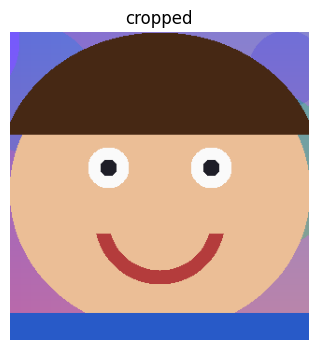

In [ ]:
# Exercise 1.1 — CROP: extract just the face
# (roughly rows 90 to 420, columns 160 to 480). No loops!
face = img[90:420,160:480,:3]
show(face, titles=["cropped"])

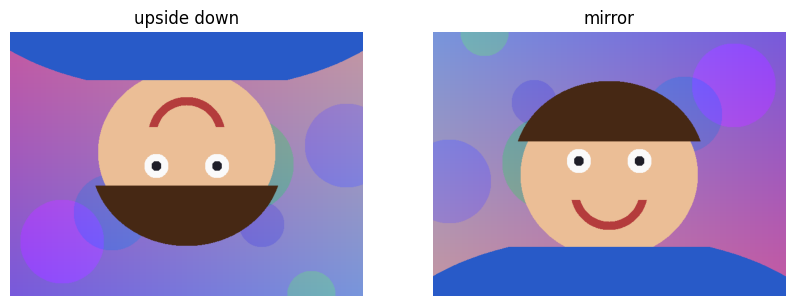

In [ ]:
# Exercise 1.2 — FLIPS: using only slicing with negative steps (::-1),
# make an upside-down version and a mirrored version.
upside_down = img[::-1]
mirrored    = img[:, ::-1]
show(upside_down, mirrored, titles=["upside down", "mirror"])

(480, 640)


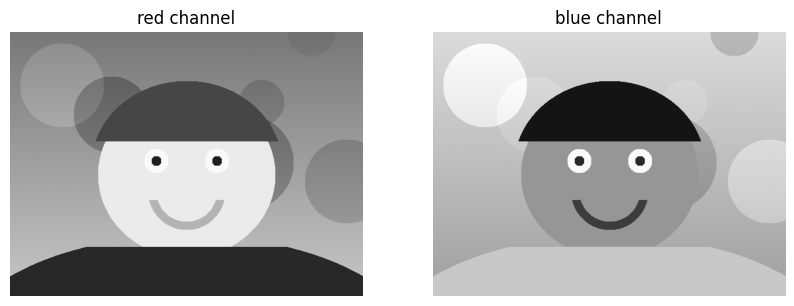

In [ ]:
# Exercise 1.3 — CHANNEL X-RAY: extract just the red channel as a 2-D array.
red = img[:, :, 0]
print(red.shape)
blue=img[:,:,2]
show(red, blue, gray="True", titles=["red channel","blue channel"])

(960, 1280, 3)


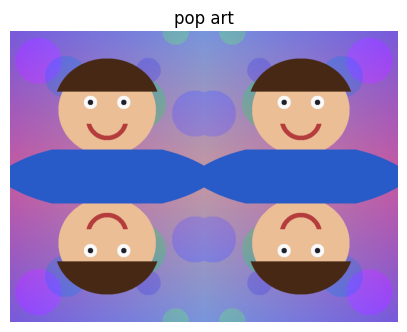

In [ ]:
# Exercise 1.4 — WARHOL GRID: ONE image containing a 2x2 grid:
#   top:    original    | mirrored
#   bottom: upside down | upside down AND mirrored
# Hint: np.hstack / np.vstack take a TUPLE of arrays.
top = np.hstack((img,mirrored))
bottom=np.hstack((upside_down,img[::-1,::-1]))
warhol = np.vstack((top,bottom))
print(warhol.shape)   # should be (960, 1280, 3)
show(warhol, titles=["pop art"])

✅ **Checkpoint 1:** Warhol grid is `(960, 1280, 3)`. **Code check before Part 2.**

---
## Part 2 · Broadcasting Filters 🎨

In [8]:
# THE uint8 TRAP — run this and look carefully.
pixel = np.array([200, 100, 50], dtype=np.uint8)
print("pixel + 100 =", pixel + 100)     # 200 + 100 = ...44?!
# uint8 holds 0..255, so 300 wraps to 44. Rule: float -> math -> clip -> uint8:
img_f = img.astype(np.float64)
print("safe:", np.clip(img_f[0, 0] + 100, 0, 255).astype(np.uint8))

pixel + 100 = [ 44 200 150]
safe: [220 190 255]


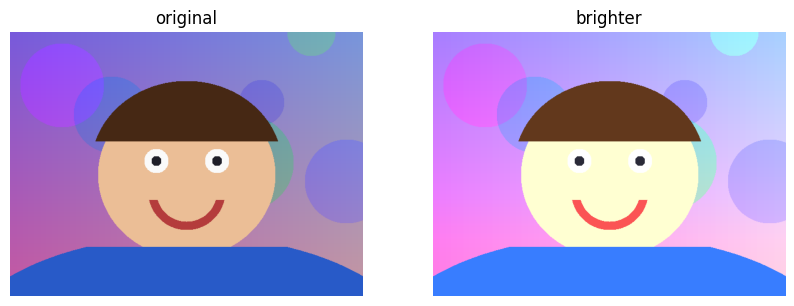

In [ ]:
# Exercise 2.1 — BRIGHTNESS: 40% brighter. Multiply img_f by 1.4,
# clip to 0..255, convert back to uint8.
brighter = np.clip(img_f * 1.4,0,255).astype(np.uint8)
show(img, brighter, titles=["original", "brighter"])

(480, 640)


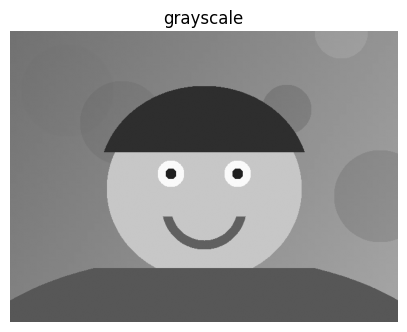

In [ ]:
# Exercise 2.2 — GRAYSCALE: real grayscale is a WEIGHTED sum:
#   gray = 0.299*R + 0.587*G + 0.114*B   (eyes love green)
# One line with @:  (480, 640, 3) @ (3,)  ->  (480, 640)
weights = np.array([0.299, 0.587, 0.114])
gray = img_f @ weights
print(gray.shape)
show(gray, gray=True, titles=["grayscale"])

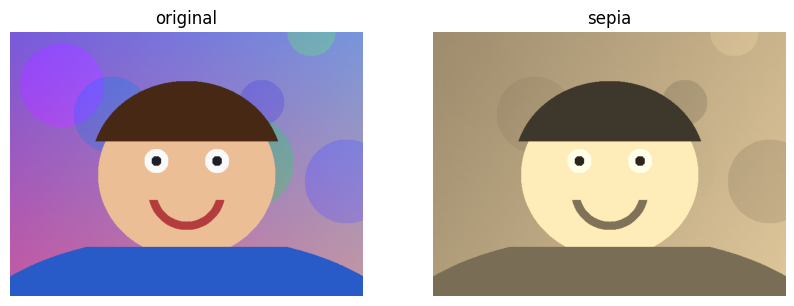

In [ ]:
# Exercise 2.3 — SEPIA: every output pixel = 3x3 matrix times input pixel.
sepia_matrix = np.array([[0.393, 0.769, 0.189],
                         [0.349, 0.686, 0.168],
                         [0.272, 0.534, 0.131]])
sepia = np.clip(img_f @ sepia_matrix.T, 0,255).astype(np.uint8)
# TODO: img_f @ sepia_matrix.T, clip, uint8. (Why .T?)
show(img, sepia, titles=["original", "sepia"])

(480, 640) (480, 640)


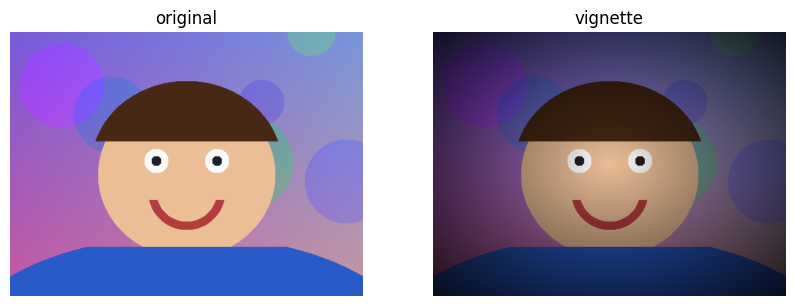

In [ ]:
# Exercise 2.4 — VIGNETTE (dark corners). Broadcasting boss level.
#   1. ys = np.linspace(-1, 1, 480) as a COLUMN: shape (480, 1)
#   2. xs = np.linspace(-1, 1, 640) as a ROW:    shape (1, 640)
#   3. dist = np.sqrt(xs**2 + ys**2)  -> broadcasts to (480, 640)!
#   4. fade = np.clip(1 - 0.6 * dist, 0, 1)
#   5. img_f * fade — shapes don't match... np.newaxis to the rescue.
ys   = np.linspace(-1,1,480).reshape(-1,1)
xs   = np.linspace(-1,1,640).reshape(1,-1)
dist = np.sqrt(xs**2 + ys**2)
fade = np.clip(1 - 0.6 * dist, 0, 1)
vignette = np.clip(img_f * fade[:,:, np.newaxis],0,255).astype(np.uint8)
print(dist.shape, fade.shape)
show(img, vignette, titles=["original", "vignette"])

In [ ]:
# THE GREAT SPEED RACE 🏁 — why the One Rule exists.
import time
t0 = time.perf_counter()
slow = np.zeros_like(img)
for r in range(img.shape[0]):
    for c in range(img.shape[1]):
        for ch in range(3):
            slow[r, c, ch] = min(int(img[r, c, ch] * 1.4), 255)
t_loop = time.perf_counter() - t0
t0 = time.perf_counter()
fast = np.clip(img.astype(np.float64) * 1.4, 0, 255).astype(np.uint8)
t_np = time.perf_counter() - t0
print(f"triple loop: {t_loop:.3f} s")
print(f"NumPy:       {t_np:.5f} s")
print(f"NumPy is {t_loop / t_np:,.0f}x faster")

triple loop: 4.421 s
NumPy:       0.00557 s
NumPy is 794x faster


✅ **Checkpoint 2:** four filters done, NumPy crushed the loop.

---
## Part 3 · Green-Screen Movie Magic 🎬
Hollywood compositing = **boolean array indexing**.

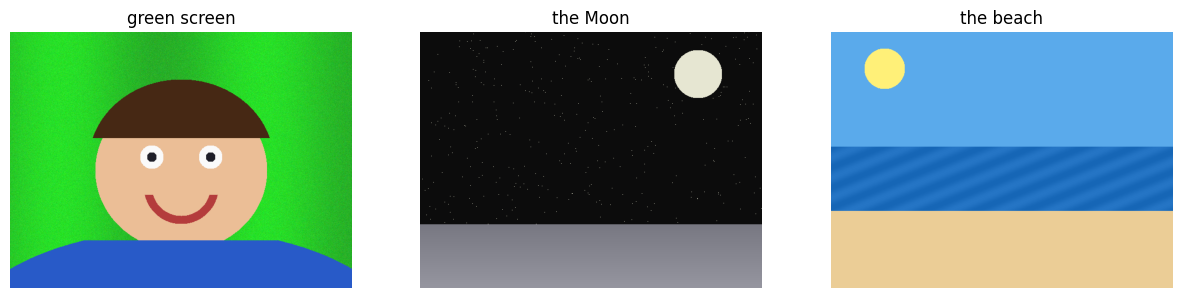

In [ ]:
gs    = load("/greenscreen.png")
moon  = load("/background_moon.png")
beach = load("/background_beach.png")
show(gs, moon, beach, titles=["green screen", "the Moon", "the beach"])

In [ ]:
# Exercise 3.1 — SCOUT: print mean R, G, B of the top-left 50x50 corner
# (pure screen) so you know what "green screen green" is numerically.
gsmean=(gs[:50, :50]).mean()
print(gsmean)

96.15573333333333


(480, 640) bool


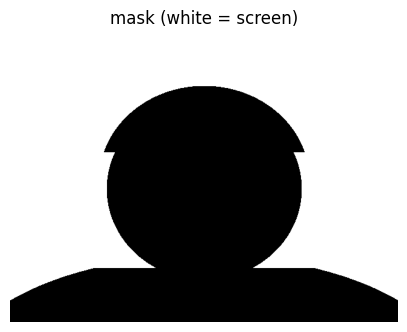

In [ ]:
# Exercise 3.2 — MASK: a boolean array, True where the pixel is green-screen.
# Combine TWO conditions with np.logical_and (from the Week 5 slides!),
# using your stats from 3.1 to pick the thresholds.
mask = np.logical_and(gs[:,:,1]>gsmean,gs[:,:,0]<gsmean)
# TODO: np.logical_and(green channel > ___, red channel < ___)
print(mask.shape, mask.dtype)
show(mask * 255, gray=True, titles=["mask (white = screen)"])

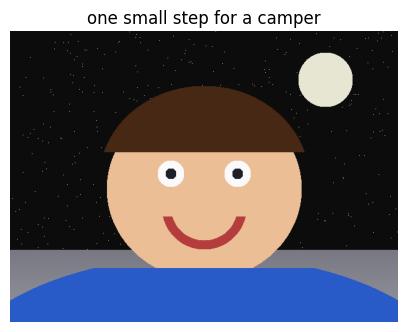

In [ ]:
# Exercise 3.3 — COMPOSITE with np.where(condition, if_true, if_false).
# Shape puzzle: mask is (480,640), images are (480,640,3)...
#make moon the background
on_moon = np.where(mask[:,:,None],moon,gs)
show(on_moon, titles=["one small step for a camper"])

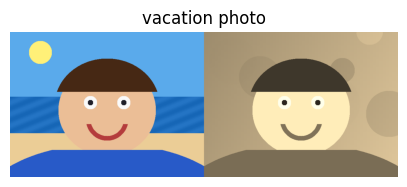

In [ ]:
# Exercise 3.4 — VACATION PHOTO: composite onto the beach, apply your
# favorite Part-2 filter on top, np.hstack a side-by-side postcard.
on_beach = np.where(mask[:,:,None],beach,gs)
filter = np.hstack((on_beach,sepia))
show(filter, titles=["vacation photo"])

✅ **Checkpoint 3:** camper on the Moon, clean edges. **Code check.**

---
## Part 4 · Photo Forensics 🕵️ — the challenge tier
A hillside photo was submitted as evidence... but the original surfaced too.
The forger made **two** edits. Find both — *with statistics, not eyeballs*.

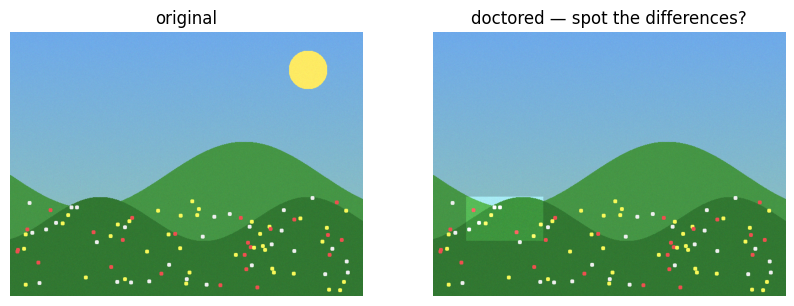

In [ ]:
orig = load("/scene_original.png").astype(np.int64)   # we need negatives!
doc  = load("/scene_doctored.png").astype(np.int64)
show(orig, doc, titles=["original", "doctored — spot the differences?"])

max difference: 135


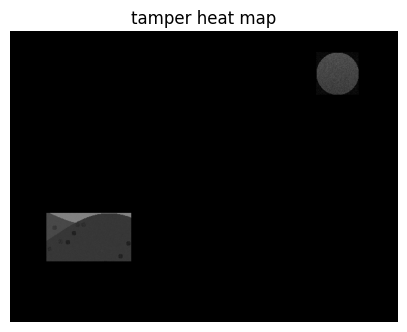

In [ ]:
# Exercise 4.1 — DIFFERENCE MAP: per-pixel absolute difference, summed over
# channels -> 2-D tamper heat map. (Why int64 first? What's 10 - 200 in uint8?)
diff = np.sum(np.abs(orig - doc), axis=-1).astype(np.uint8)
# TODO: shape (480, 640)
print("max difference:", diff.max())
show(diff, gray=True, titles=["tamper heat map"])

In [ ]:
# Exercise 4.2 — LOCATE: np.argwhere(diff > 30) gives (N, 2) [row, col]
# coordinates. Report min/max row and col — then split the coords to report
# EACH tampered region separately.
coords = np.argwhere(diff > 30)
left  = coords[coords[:, 1] < 320]
right = coords[coords[:, 1] > 320]
print("rows", left[:, 0].min(), "to", left[:, 0].max())
print("cols", left[:, 1].min(), "to", left[:, 1].max())
print("rows", right[:, 0].min(), "to", right[:, 0].max())
print("cols", right[:, 1].min(), "to", right[:, 1].max())

rows 300 to 379
cols 60 to 199
rows 36 to 104
cols 506 to 574


In [ ]:
# Exercise 4.3 — CHARACTERIZE: for the field region, compare doc vs orig with
# np.mean. The forger applied one simple math operation — which, with what number?
# Hint: try the RATIO of the means.
origmean=np.mean(orig[300:379,60:199])
docmean=np.mean(doc[300:379,60:199])
print(docmean/origmean)
origmean2=np.mean(orig[36:104,506:574])
docmean2=np.mean(doc[36:104,506:574])
print(docmean2/origmean2)

1.234544668936553
0.896465164339247


✅ **Checkpoint 4:** cloned sky patch found AND ×1.25 brightening proven. Case closed. 🎉

---
## 🏆 Bonus Round (for the fearless)

In [6]:
# BONUS A — SECRET MESSAGE: images/secret.png looks identical to the
# portrait, but a spy wrote a message into it. Remember: text is numbers too —
# every character has an ASCII code (chr(78) is 'N', ord('N') is 78).
# The spy replaced the RED values of the first pixels in the TOP ROW with
# the ASCII codes of the message, ending with a 0.
#   1. Slice out those values:  secret[0, :60, 0]
#   2. Print them — do you see numbers in the letter range (65-90, 32)?
#   3. Convert to text: "".join(chr(v) for v in ...) and stop at the 0.
secret = load("secret.png")
print("".join(chr(v) for v in secret[0, :60, 0] if v>=65 and v<=90))

NUMPYWIZARDSRULE


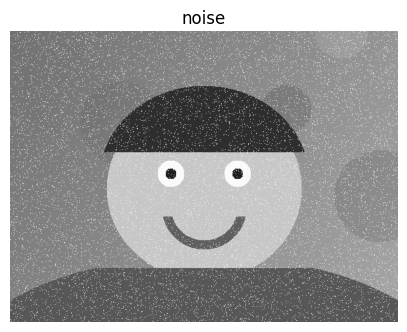

In [11]:
# BONUS B — NOISE ATTACK & REPAIR: add salt & pepper noise to a grayscale
# copy (np.random.random to pick ~4% of pixels; set some 0, some 255), then
# repair with a 3x3 MEDIAN filter — build 9 shifted copies by slicing (a loop
# over the 9 OFFSETS is allowed), np.stack, np.median(axis=0).
g = img_f @ np.array([0.299, 0.587, 0.114])
random=np.random.random(g.shape)
g=np.where(random<0.04,255,g)
show(g, gray=True, titles=["noise"])

---
## 🚀 Open-Ended Challenges — choose your own adventure
No TODO scaffolding from here on. Pick any challenge, design your own approach,
and be ready to explain **why** your solution works, not just that it does.
⭐ = tough, ⭐⭐ = very tough, ⭐⭐⭐ = show us something we haven't seen.
Rules still apply: no pixel loops.

In [ ]:
# CHALLENGE 1 ⭐ — LAUNCH YOUR FILTER BRAND
# Invent a signature filter with a NAME, combining at least THREE distinct
# operations (tint, vignette, contrast, grain, fade, channel swap, ...).
# Examples to beat: "Michigan Winter" (cold tint + heavy vignette + low
# contrast), "Golden Hour" (warm tint + soft fade + gentle grain).
# Requirements: one function  my_filter(img) -> uint8 image,  applied to BOTH
# the portrait and your green-screen composite. Judged on: originality,
# clean code, and whether your neighbor can guess the name from the look.

In [ ]:
# CHALLENGE 2 ⭐ — PENCIL SKETCH (edge detection from scratch)
# An "edge" is where neighboring pixel values change fast. You can measure
# change with SHIFTED SLICES — no loops:
#     horizontal change: gray[:, 1:] - gray[:, :-1]
#     vertical change:   gray[1:, :] - gray[:-1, :]
# Build an edge-strength map (careful: shapes differ by one — crop to match!),
# then turn it into a pencil sketch: white paper, dark lines.
# Open questions YOU decide: how to combine the two directions? what
# threshold? invert with 255 - x? Can you overlay the sketch on the photo?

In [ ]:
# CHALLENGE 3 ⭐⭐ — PRIVACY MODE (selective pixelation)
# News crews pixelate faces. Two sub-problems, both yours to design:
#   (a) Pixelate: shrink each k x k block to its average color. The famous
#       reshape trick does it with ZERO loops:
#         img.reshape(H//k, k, W//k, k, 3).mean(axis=(1, 3))
#       ...then blow it back up (np.repeat, twice, on different axes).
#   (b) Selective: pixelate ONLY a region (the face) while the rest stays
#       sharp. You already know the masking tools.
# Your choices: block size k, region shape (rectangle? ellipse using the
# circle-equation trick?), soft or hard boundary.

In [ ]:
# CHALLENGE 4 ⭐⭐ — AUTO GREEN SCREEN (no magic numbers)
# Your Part-3 mask used hand-tuned thresholds. Real software auto-detects.
# Write  auto_composite(subject, background)  that works on ANY solid-ish
# backdrop color — green, blue, hot pink — with NO hardcoded thresholds:
#   1. Estimate the backdrop color from the image itself (hint: which pixels
#      are almost certainly backdrop? Think borders. Think np.median.)
#   2. Compute each pixel's DISTANCE to that color in 3-D color space
#      (one np.linalg.norm or a sqrt-of-sums — broadcasting again).
#   3. Threshold the distance — but derive the threshold from the data too
#      (np.percentile of the border distances?).
# Test: it must work on greenscreen.png UNCHANGED, then still work if you
# swap the green for another color (hint: gs[:, :, [2, 1, 0]]).

In [ ]:
# CHALLENGE 5 ⭐⭐⭐ — FORENSICS WITHOUT THE ORIGINAL
# In Part 4 you had the original for comparison. Real forensic analysts don't.
# Using ONLY scene_doctored.png, find evidence of the clone-stamp edit.
# One powerful idea: the pasted patch is an EXACT COPY of another region, so
# somewhere two patches match far too perfectly (real photos have unique
# sensor noise everywhere — that's why the photo is grainy!).
# Design your own detector. Possible directions (pick one, or invent):
#   - shift-and-compare: subtract the image from a SHIFTED copy of itself
#     (slicing, or np.roll). The result is suspiciously tiny where the clone
#     and its source align. What shift? Can you SEARCH over shifts? (A loop
#     over candidate shifts is allowed — hypotheses, not pixels.)
#   - local texture: compute a block std-dev map via the reshape trick from
#     Challenge 3 — cloned sky vs real sky may differ from surroundings.
# Deliverable: a heat map + a one-paragraph "expert testimony" explaining
# your evidence. Partial detections welcome — argue what you found.

In [ ]:
# CHALLENGE 6 ⭐⭐⭐ — FUNHOUSE MIRROR (warp reality with fancy indexing)
# Integer array indexing (from the slides!) lets you build a NEW image by
# telling NumPy which source pixel to grab for every output pixel:
#     rows = np.arange(480)[:, np.newaxis]        # (480, 1)
#     cols = np.arange(640)[np.newaxis, :]        # (1, 640)
#     copy = img[rows, cols]                      # boring... so far
# Now BEND the coordinates before indexing. A wavy mirror:
#     wavy_cols = (cols + 25 * np.sin(rows / 30)).astype(int) % 640
#     warped = img[rows, wavy_cols]
# Your mission: invent at least TWO of your own distortions. Ideas to riff on:
# a funhouse bulge (stretch coordinates near the center), a whirlpool (rotate
# by an angle that grows with distance from center — you have dist from the
# vignette!), a glitch effect (shift each row by a random amount), underwater
# ripples (waves in BOTH axes)... Explain the coordinate math for each.

### How you'll be judged (all challenges)
1. **It runs** and obeys the One Rule.
2. **You can explain it** — every line, every threshold, every shape.
3. **You made choices** — and can say what you tried that *didn't* work.
Nobody finishes all six. Depth beats coverage. 🏔️

---
## 🖼️ Ship It — Gallery Walk
Compose one stacked image of your three favorite creations (`np.hstack`/`np.vstack`),
then `plt.imsave("my_exhibit.png", exhibit)`.

**Used today:** shape & dtype · slicing · negative strides · stacking · broadcasting ·
`np.newaxis` · `@` · ufuncs & `np.clip` · `np.logical_and` · boolean masks & `np.where` ·
integer (fancy) indexing · `np.argwhere` · `np.mean`/`np.median` · `np.random`

You didn't just learn NumPy today. You built Photoshop. 🧪